In [11]:
import os
import pandas as pd
import numpy as np
import librosa
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torchvision import models
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from tqdm import tqdm  


In [12]:
DATASET_ROOT = '/kaggle/input/datasets/chrisfilo/urbansound8k'
AUDIO_DIR = DATASET_ROOT 
METADATA_PATH = os.path.join(DATASET_ROOT, 'UrbanSound8K.csv')

if not os.path.exists(METADATA_PATH):
    alt_path = os.path.join(DATASET_ROOT, 'UrbanSound8K', 'UrbanSound8K.csv')
    if os.path.exists(alt_path):
        METADATA_PATH = alt_path

print(f"METADATA_PATH: {METADATA_PATH}")
print(f"AUDIO_DIR: {AUDIO_DIR}")

SAMPLE_RATE = 16000
SAMPLES_LEN = int(SAMPLE_RATE * 4.0)
N_MELS = 64

METADATA_PATH: /kaggle/input/datasets/chrisfilo/urbansound8k/UrbanSound8K.csv
AUDIO_DIR: /kaggle/input/datasets/chrisfilo/urbansound8k


In [13]:
def add_noise(data, noise_factor=0.01):
    noise = np.random.randn(len(data))
    return data + noise_factor * noise

def time_shift(data, sampling_rate, shift_max=0.25):
    shift = np.random.randint(sampling_rate * shift_max)
    return np.roll(data, shift)

def pitch_shift(data, sampling_rate, n_steps=3.0):
    return librosa.effects.pitch_shift(data, sr=sampling_rate, n_steps=n_steps)

def process_audio_data(audio):
    if len(audio) >= SAMPLES_LEN:
        audio = audio[:SAMPLES_LEN]
    else:
        padding = SAMPLES_LEN - len(audio)
        audio = np.pad(audio, (0, padding), 'constant')
        
    melspec = librosa.feature.melspectrogram(y=audio, sr=SAMPLE_RATE, n_mels=N_MELS)
    melspec = librosa.power_to_db(melspec, ref=np.max)
    
    m_min, m_max = melspec.min(), melspec.max()
    if m_max - m_min > 1e-6:
        melspec = (melspec - m_min) / (m_max - m_min)
    else:
        melspec = np.zeros_like(melspec)
        
    raw_tensor = torch.tensor(audio, dtype=torch.float32).unsqueeze(0)
    spec_tensor = torch.tensor(melspec, dtype=torch.float32).unsqueeze(0)
    
    return raw_tensor, spec_tensor

def create_dataset(df, augment=False):
    raw_list = []
    spec_list = []
    label_list = []
    
    for _, row in tqdm(df.iterrows(), total=len(df)):
        filename = row['slice_file_name']
        fold = row['fold']
        class_id = row['classID']
        file_path = os.path.join(AUDIO_DIR, f"fold{fold}", filename)
        
        try:
            audio, _ = librosa.load(file_path, sr=SAMPLE_RATE, mono=True)
            
            r, s = process_audio_data(audio)
            raw_list.append(r)
            spec_list.append(s)
            label_list.append(class_id)
            
            if augment:
                audio_noise = add_noise(audio)
                r_n, s_n = process_audio_data(audio_noise)
                raw_list.append(r_n)
                spec_list.append(s_n)
                label_list.append(class_id)
                
                audio_shift = time_shift(audio, SAMPLE_RATE)
                r_s, s_s = process_audio_data(audio_shift)
                raw_list.append(r_s)
                spec_list.append(s_s)
                label_list.append(class_id)
                
                audio_pitch = pitch_shift(audio, SAMPLE_RATE)
                r_p, s_p = process_audio_data(audio_pitch)
                aw_list.append(r_p)
                spec_list.append(s_p)
                label_list.append(class_id)

        except Exception as e:
            continue
            
    return torch.stack(raw_list), torch.stack(spec_list), torch.tensor(label_list, dtype=torch.long)

In [14]:
df = pd.read_csv(METADATA_PATH)
train_df = df[df['fold'] != 9].copy()
test_df = df[df['fold'] == 9].copy()

X_train_raw, X_train_spec, y_train = create_dataset(train_df, augment=True)
X_test_raw, X_test_spec, y_test = create_dataset(test_df, augment=False)

print(f"X_train_raw: {X_train_raw.shape}")
print(f"X_train_spec: {X_train_spec.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test_raw: {X_test_raw.shape}")

 24%|██▍       | 1910/7916 [02:55<09:43, 10.30it/s]/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1551
  warnings.warn(
 24%|██▍       | 1913/7916 [02:55<07:55, 12.63it/s]/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1757
  warnings.warn(
 25%|██▌       | 1982/7916 [03:01<10:18,  9.59it/s]/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1600
  warnings.warn(
 32%|███▏      | 2505/7916 [03:49<08:08, 11.07it/s]/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1918
  warnings.warn(
 34%|███▍      | 2681/7916 [04:06<05:21, 16.30it/s]/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input sign

X_train_raw: torch.Size([23748, 1, 64000])
X_train_spec: torch.Size([23748, 1, 64, 126])
y_train: torch.Size([23748])
X_test_raw: torch.Size([816, 1, 64000])


In [15]:
class Simple1DCNN(nn.Module):
    def __init__(self, num_classes=10, pooling_type='max'):
        super().__init__()
        self.pooling_type = pooling_type
        
        self.conv1 = nn.Conv1d(1, 16, kernel_size=80, stride=4)
        self.bn1 = nn.BatchNorm1d(16)
        
        self.conv2 = nn.Conv1d(16, 32, kernel_size=3)
        self.bn2 = nn.BatchNorm1d(32)
        
        self.conv3 = nn.Conv1d(32, 64, kernel_size=3)
        self.bn3 = nn.BatchNorm1d(64)
        
        self.conv4 = nn.Conv1d(64, 128, kernel_size=3)
        self.bn4 = nn.BatchNorm1d(128)

        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.max_pool1d(x, 4)
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.max_pool1d(x, 4)
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.max_pool1d(x, 4)
        x = F.relu(self.bn4(self.conv4(x)))
        
        if self.pooling_type == 'max':
            x = F.adaptive_max_pool1d(x, 1) 
        else:
            x = F.adaptive_avg_pool1d(x, 1)
            
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

class ResBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)
        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class ResNet1D(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 32, kernel_size=80, stride=4, padding=38, bias=False)
        self.bn1 = nn.BatchNorm1d(32)
        
        self.layer1 = self._make_layer(32, 32, stride=1)
        self.layer2 = self._make_layer(32, 64, stride=2)
        self.layer3 = self._make_layer(64, 128, stride=2)
        self.layer4 = self._make_layer(128, 256, stride=2)
        
        self.fc = nn.Linear(256, num_classes)

    def _make_layer(self, in_c, out_c, stride):
        return nn.Sequential(
            ResBlock1D(in_c, out_c, stride),
            ResBlock1D(out_c, out_c, 1)
        )

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.max_pool1d(x, 4)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = F.adaptive_avg_pool1d(x, 1)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

class AudioEfficientNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.base_model = models.efficientnet_b0(weights='DEFAULT')
        self.base_model.features[0][0] = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1, bias=False)
        self.base_model.classifier[1] = nn.Linear(1280, num_classes)

    def forward(self, x):
        return self.base_model(x)

In [24]:
def get_loaders(X_train, y_train, X_test, y_test, batch_size=32):
    train_ds = TensorDataset(X_train, y_train)
    test_ds = TensorDataset(X_test, y_test)
    
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)
    
    return train_loader, test_loader


def train_model(model, train_loader, val_loader, epochs=15, lr=0.001):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device} | LR: {lr}")
    
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    history = {'train_loss': [], 'train_acc': [], 'train_f1': [],
               'val_loss': [], 'val_acc': [], 'val_f1': []}
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        all_train_preds = []
        all_train_labels = []
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=True)
        
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_train_preds.extend(predicted.cpu().numpy())
            all_train_labels.extend(labels.cpu().numpy())
            
            pbar.set_postfix({'loss': loss.item()})
            
        train_loss = running_loss / total
        train_acc = correct / total
        train_f1 = f1_score(all_train_labels, all_train_preds, average='macro')
        
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        all_val_preds = []
        all_val_labels = []
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
                
                all_val_preds.extend(predicted.cpu().numpy())
                all_val_labels.extend(labels.cpu().numpy())
                
        val_loss = val_loss / val_total
        val_acc = val_correct / val_total
        val_f1 = f1_score(all_val_labels, all_val_preds, average='macro')
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['train_f1'].append(train_f1)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        
        print(f"Epoch {epoch+1} Summary: Train Acc {train_acc:.4f} | Val Acc {val_acc:.4f} | Val F1 {val_f1:.4f}")
        
    return model, history

def plot_results(history, title):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
    
    ax1.plot(epochs, history['train_loss'], 'b-', label='Train')
    ax1.plot(epochs, history['val_loss'], 'r--', label='Val')
    ax1.set_title(f'{title}: Loss')
    ax1.legend()
    
    ax2.plot(epochs, history['train_acc'], 'b-', label='Train')
    ax2.plot(epochs, history['val_acc'], 'r--', label='Val')
    ax2.set_title(f'{title}: Accuracy')
    ax2.legend()

    ax3.plot(epochs, history['train_f1'], 'b-', label='Train')
    ax3.plot(epochs, history['val_f1'], 'r--', label='Val')
    ax3.set_title(f'{title}: F1-Score')
    ax3.legend()
    
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(model, loader, classes):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.show()
    print(classification_report(all_labels, all_preds, target_names=classes))

In [27]:
CLASSES = ['Air Conditioner', 'Car Horn', 'Children Playing', 'Dog Bark', 
           'Drilling', 'Engine Idling', 'Gun Shot', 'Jackhammer', 
           'Siren', 'Street Music']

EPOCHS = 10
BATCH_SIZE = 64
LR_SIMPLE = 1e-4
LR_RESNET = 5e-4
LR_EFFNET = 5e-4

In [28]:
train_dl_raw, test_dl_raw = get_loaders(
    X_train_raw, y_train, 
    X_test_raw, y_test, 
    BATCH_SIZE
)
train_dl_spec, test_dl_spec = get_loaders(
    X_train_spec, y_train, 
    X_test_spec, y_test, 
    BATCH_SIZE
)

Device: cuda | LR: 0.0001


Epoch 1/10: 100%|██████████| 372/372 [00:09<00:00, 39.93it/s, loss=1.88]


Epoch 1 Summary: Train Acc 0.3752 | Val Acc 0.5123 | Val F1 0.5011


Epoch 2/10: 100%|██████████| 372/372 [00:09<00:00, 40.23it/s, loss=1.56]


Epoch 2 Summary: Train Acc 0.5199 | Val Acc 0.5453 | Val F1 0.5531


...

Epoch 8 Summary: Train Acc 0.6893 | Val Acc 0.6287 | Val F1 0.6559


Epoch 9/10: 100%|██████████| 372/372 [00:09<00:00, 39.90it/s, loss=1.68] 


Epoch 9 Summary: Train Acc 0.7028 | Val Acc 0.6409 | Val F1 0.6656


Epoch 10/10: 100%|██████████| 372/372 [00:09<00:00, 39.98it/s, loss=1.43] 


Epoch 10 Summary: Train Acc 0.7139 | Val Acc 0.6299 | Val F1 0.6485


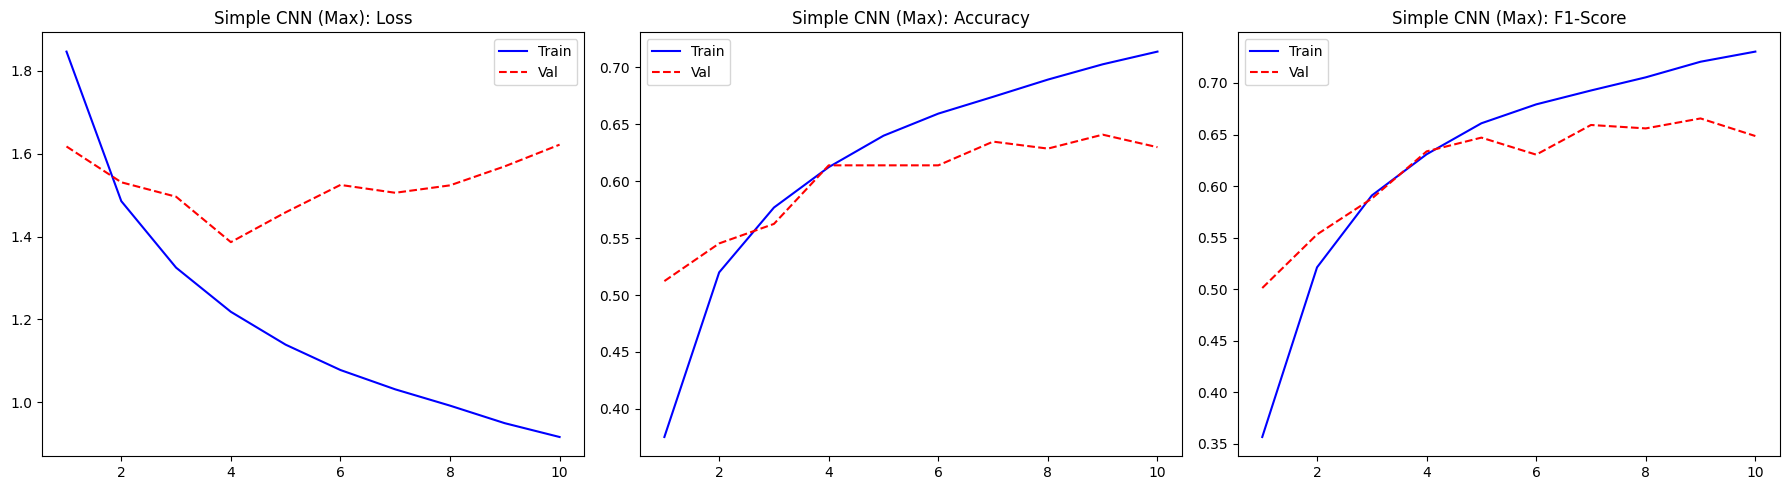

In [29]:
model_m1 = Simple1DCNN(pooling_type='max')
model_m1, hist_m1 = train_model(model_m1, train_dl_raw, test_dl_raw, epochs=EPOCHS, lr=LR_SIMPLE)
plot_results(hist_m1, "Simple CNN (Max)")

Device: cuda | LR: 0.0001


Epoch 1/10: 100%|██████████| 372/372 [00:09<00:00, 40.09it/s, loss=2.48]


Epoch 1 Summary: Train Acc 0.3596 | Val Acc 0.3946 | Val F1 0.3308


Epoch 2/10: 100%|██████████| 372/372 [00:09<00:00, 39.70it/s, loss=1.76]


Epoch 2 Summary: Train Acc 0.4485 | Val Acc 0.4301 | Val F1 0.3930


...

Epoch 8 Summary: Train Acc 0.6138 | Val Acc 0.4828 | Val F1 0.4668


Epoch 9/10: 100%|██████████| 372/372 [00:09<00:00, 39.81it/s, loss=2.14] 


Epoch 9 Summary: Train Acc 0.6254 | Val Acc 0.5012 | Val F1 0.4944


Epoch 10/10: 100%|██████████| 372/372 [00:09<00:00, 39.91it/s, loss=1.88] 


Epoch 10 Summary: Train Acc 0.6330 | Val Acc 0.4902 | Val F1 0.4871


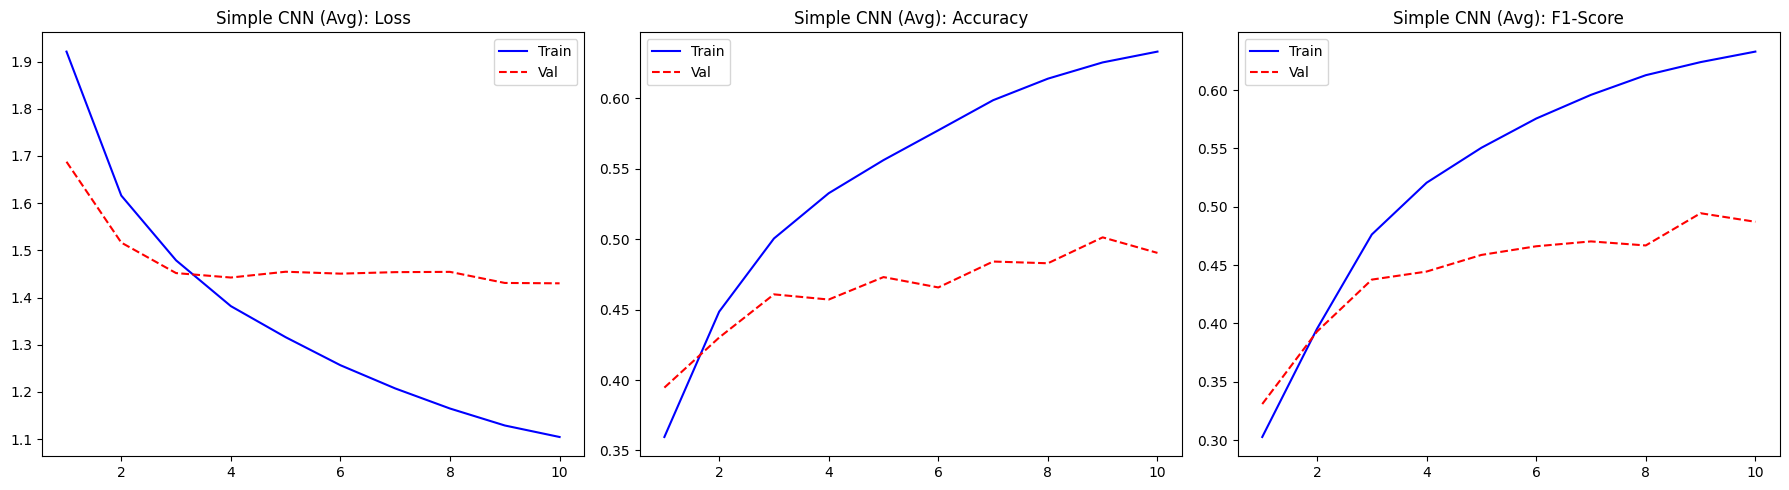

In [31]:
model_m2 = Simple1DCNN(pooling_type='avg')
model_m2, hist_m2 = train_model(model_m2, train_dl_raw, test_dl_raw, epochs=EPOCHS, lr=LR_SIMPLE)
plot_results(hist_m2, "Simple CNN (Avg)")

Device: cuda | LR: 0.0005


Epoch 1/10: 100%|██████████| 372/372 [00:35<00:00, 10.62it/s, loss=1.76] 


Epoch 1 Summary: Train Acc 0.4947 | Val Acc 0.4926 | Val F1 0.4736


Epoch 2/10: 100%|██████████| 372/372 [00:34<00:00, 10.65it/s, loss=1.33] 


Epoch 2 Summary: Train Acc 0.6321 | Val Acc 0.5466 | Val F1 0.5463


...

Epoch 8 Summary: Train Acc 0.8182 | Val Acc 0.5944 | Val F1 0.5282


Epoch 9/10: 100%|██████████| 372/372 [00:34<00:00, 10.65it/s, loss=1.38] 


Epoch 9 Summary: Train Acc 0.8394 | Val Acc 0.6458 | Val F1 0.6501


Epoch 10/10: 100%|██████████| 372/372 [00:34<00:00, 10.64it/s, loss=2.19] 


Epoch 10 Summary: Train Acc 0.8425 | Val Acc 0.6373 | Val F1 0.6586


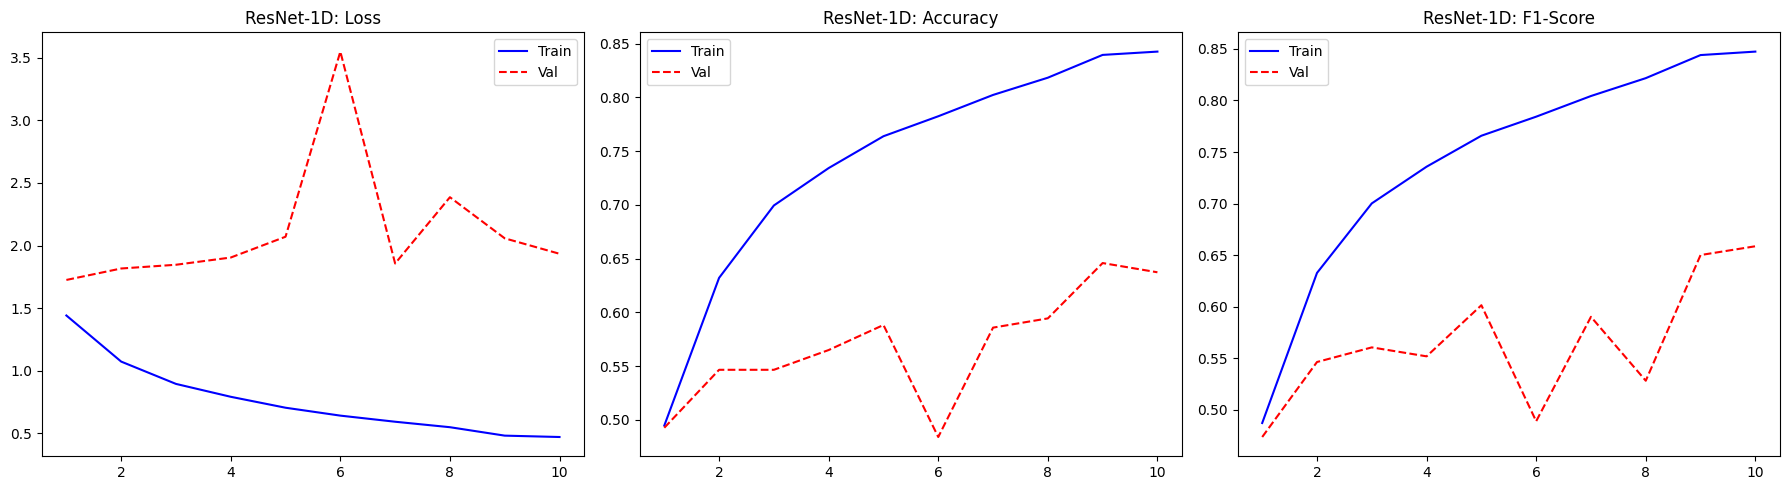

In [32]:
model_m3 = ResNet1D()
model_m3, hist_m3 = train_model(model_m3, train_dl_raw, test_dl_raw, epochs=EPOCHS, lr=LR_RESNET)
plot_results(hist_m3, "ResNet-1D")

In [33]:
train_dl_spec, test_dl_spec = get_loaders(X_train_spec, y_train, X_test_spec, y_test, BATCH_SIZE)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 220MB/s]


Device: cuda | LR: 0.0005


Epoch 1/10: 100%|██████████| 372/372 [00:22<00:00, 16.51it/s, loss=2.79] 


Epoch 1 Summary: Train Acc 0.7832 | Val Acc 0.7770 | Val F1 0.7841


...

Epoch 8 Summary: Train Acc 0.9774 | Val Acc 0.8051 | Val F1 0.8213


Epoch 9/10: 100%|██████████| 372/372 [00:22<00:00, 16.66it/s, loss=0.0481] 


Epoch 9 Summary: Train Acc 0.9829 | Val Acc 0.7904 | Val F1 0.8011


Epoch 10/10: 100%|██████████| 372/372 [00:22<00:00, 16.63it/s, loss=0.067]  


Epoch 10 Summary: Train Acc 0.9837 | Val Acc 0.7819 | Val F1 0.7874


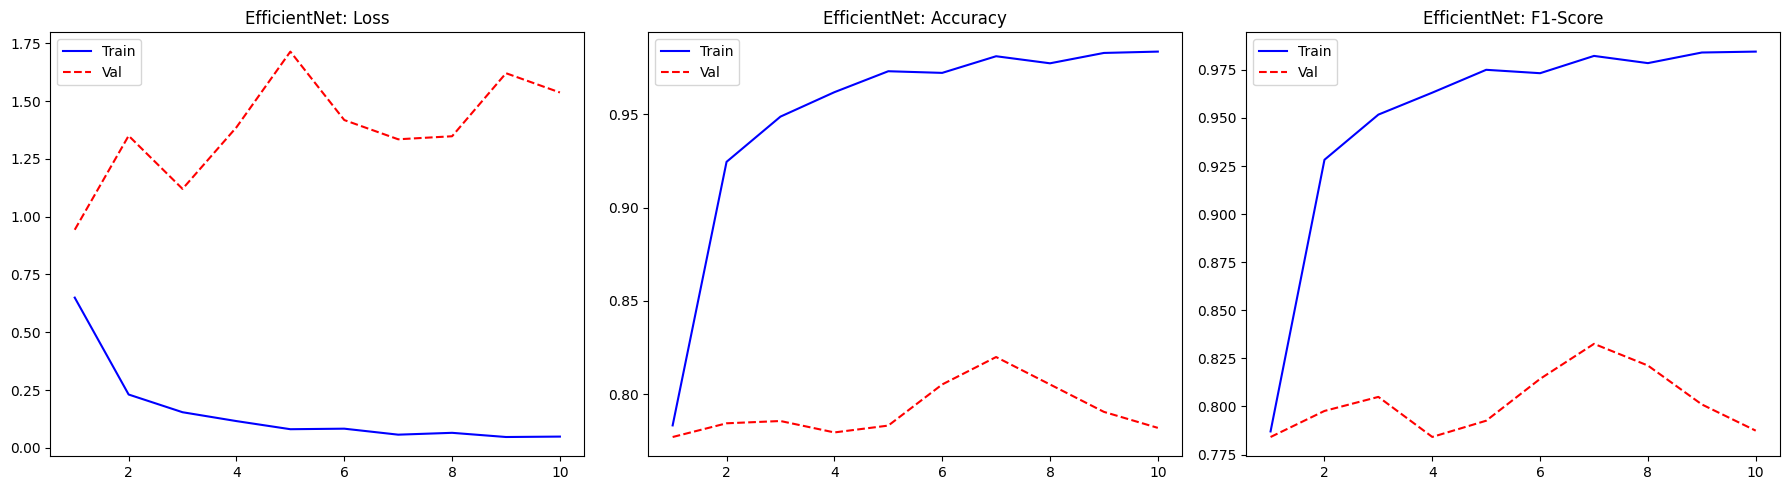

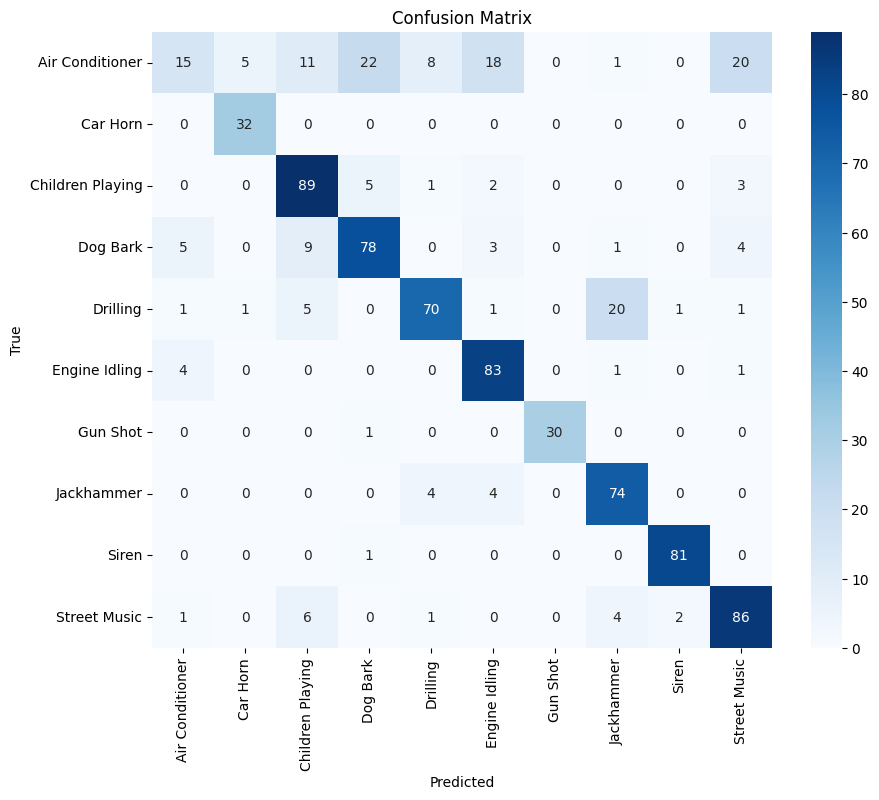

                  precision    recall  f1-score   support

 Air Conditioner       0.58      0.15      0.24       100
        Car Horn       0.84      1.00      0.91        32
Children Playing       0.74      0.89      0.81       100
        Dog Bark       0.73      0.78      0.75       100
        Drilling       0.83      0.70      0.76       100
   Engine Idling       0.75      0.93      0.83        89
        Gun Shot       1.00      0.97      0.98        31
      Jackhammer       0.73      0.90      0.81        82
           Siren       0.96      0.99      0.98        82
    Street Music       0.75      0.86      0.80       100

        accuracy                           0.78       816
       macro avg       0.79      0.82      0.79       816
    weighted avg       0.77      0.78      0.76       816



In [34]:
model_m4 = AudioEfficientNet()
model_m4, hist_m4 = train_model(model_m4, train_dl_spec, test_dl_spec, epochs=EPOCHS, lr=LR_EFFNET)
plot_results(hist_m4, "EfficientNet")
plot_confusion_matrix(model_m4, test_dl_spec, CLASSES)